# Task 4: Link Prediction

In this notebook, we predict missing edges in the knowledge graph to simulate completing missing family information.

We test a few different methods:
1. Heuristics like Jaccard and Adamic-Adar.
2. Embedding methods like Node2Vec.
3. Graph Neural Networks, specifically R-GCN (Relational Graph Convolutional Network) and RotatE/TransE.

We evaluate performance using Mean Reciprocal Rank (MRR) and Hits@K metrics.

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

# PyTorch Geometric for graph neural networks
import torch_geometric
from torch_geometric.nn import RGCNConv
from torch_geometric.data import Data

# ── Reproducibility ───────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")
print(f"PyG version: {torch_geometric.__version__}")

# ── Plot style ────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
})

Using device: cpu
PyTorch version: 2.10.0+cpu
PyG version: 2.7.0


## 1. Train/Test Split

We use the provided `train.txt` and `test.txt` files. The test set contains positive triples, but we also generate negative samples (corrupted edges) for training and evaluation purposes.

In [3]:
# ── Load raw triples ──────────────────────────────────────────────────────
def load_triples(filepath):
    """Load triples from space-separated file: head relation tail"""
    triples = []
    with open(filepath, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 3:
                triples.append(tuple(parts))
    return triples

train_raw = load_triples('../MetaFam_dataset/train.txt')
test_raw  = load_triples('../MetaFam_dataset/test.txt')

print(f"Train triples: {len(train_raw):,}")
print(f"Test triples:  {len(test_raw):,}")
print(f"\nSample train: {train_raw[:3]}")
print(f"Sample test:  {test_raw[:3]}")

Train triples: 13,821
Test triples:  590

Sample train: [('olivia0', 'sisterOf', 'selina10'), ('olivia0', 'sisterOf', 'isabella11'), ('olivia0', 'sisterOf', 'oskar24')]
Sample test:  [('olivia0', 'motherOf', 'nico4'), ('katharina1', 'motherOf', 'olivia0'), ('emma7', 'motherOf', 'katharina1')]


In [4]:
# ── Build entity and relation vocabularies ───────────────────────────────
# We need mappings for ALL entities appearing in train OR test
all_triples = train_raw + test_raw
entities = sorted(set(h for h, r, t in all_triples) | set(t for h, r, t in all_triples))
relations = sorted(set(r for h, r, t in all_triples))

entity2id = {e: i for i, e in enumerate(entities)}
relation2id = {r: i for i, r in enumerate(relations)}
id2entity = {i: e for e, i in entity2id.items()}
id2relation = {i: r for r, i in relation2id.items()}

num_entities = len(entity2id)
num_relations = len(relation2id)

print(f"Entities:  {num_entities:,}")
print(f"Relations: {num_relations}")
print(f"\nRelation types: {relations}")

Entities:  1,316
Relations: 28

Relation types: ['auntOf', 'boyCousinOf', 'boyFirstCousinOnceRemovedOf', 'boySecondCousinOf', 'brotherOf', 'daughterOf', 'fatherOf', 'girlCousinOf', 'girlFirstCousinOnceRemovedOf', 'girlSecondCousinOf', 'granddaughterOf', 'grandfatherOf', 'grandmotherOf', 'grandsonOf', 'greatAuntOf', 'greatGranddaughterOf', 'greatGrandfatherOf', 'greatGrandmotherOf', 'greatGrandsonOf', 'greatUncleOf', 'motherOf', 'nephewOf', 'nieceOf', 'secondAuntOf', 'secondUncleOf', 'sisterOf', 'sonOf', 'uncleOf']


In [5]:
# ── Convert triples to IDs ────────────────────────────────────────────────
def triples_to_ids(triples, entity2id, relation2id):
    """Convert (head_str, rel_str, tail_str) → (head_id, rel_id, tail_id)"""
    return [(entity2id[h], relation2id[r], entity2id[t]) for h, r, t in triples]

train_ids = triples_to_ids(train_raw, entity2id, relation2id)
test_ids  = triples_to_ids(test_raw, entity2id, relation2id)

# ── Split train into train/val (90/10) ────────────────────────────────────
random.shuffle(train_ids)
val_size = int(len(train_ids) * 0.1)
val_ids   = train_ids[:val_size]
train_ids = train_ids[val_size:]

print(f"Final splits:")
print(f"  Train: {len(train_ids):,} triples")
print(f"  Val:   {len(val_ids):,} triples")
print(f"  Test:  {len(test_ids):,} triples")

# Convert to tensors
train_triples = torch.LongTensor(train_ids)
val_triples   = torch.LongTensor(val_ids)
test_triples  = torch.LongTensor(test_ids)

print(f"\nTensor shapes: train={train_triples.shape}, val={val_triples.shape}, test={test_triples.shape}")

Final splits:
  Train: 12,439 triples
  Val:   1,382 triples
  Test:  590 triples

Tensor shapes: train=torch.Size([12439, 3]), val=torch.Size([1382, 3]), test=torch.Size([590, 3])


## 2. Heuristic Baselines

We compute similarity scores for unconnected pairs using Jaccard Coefficient (intersection over union of neighbors) and Adamic-Adar (weighted intersection). These methods do not account for relation types, so they serve as weak baselines.

In [6]:
# ── Build PyG graph from training triples ─────────────────────────────────
# We include inverse edges: for each (h, r, t), add (t, r+num_relations, h)
# This helps GNN propagate info in both directions

def build_edge_index(triples, num_relations):
    """
    Build edge_index and edge_type tensors with original + inverse edges.
    """
    src = triples[:, 0]
    rel = triples[:, 1]
    dst = triples[:, 2]
    
    # Add inverse edges
    src_all = torch.cat([src, dst])
    dst_all = torch.cat([dst, src])
    rel_all = torch.cat([rel, rel + num_relations])  # inverse relations
    
    edge_index = torch.stack([src_all, dst_all], dim=0)
    edge_type = rel_all
    
    return edge_index, edge_type

# Build graph from training data only
edge_index, edge_type = build_edge_index(train_triples, num_relations)
edge_index = edge_index.to(DEVICE)
edge_type = edge_type.to(DEVICE)

print(f"Training graph:")
print(f"  Nodes: {num_entities:,}")
print(f"  Edges: {edge_index.shape[1]:,} (includes inverse)")
print(f"  Edge types: {num_relations * 2} (original + inverse)")

Training graph:
  Nodes: 1,316
  Edges: 24,878 (includes inverse)
  Edge types: 56 (original + inverse)


## 3. Node2Vec for Link Prediction

We use the Node2Vec embeddings trained in Task 2. The link prediction score for an edge `(u, v)` is calculated as the cosine similarity or dot product of their embeddings. Alternatively, we can train a binary classifier on the Hadamard product of edge embeddings.

In [7]:
class RGCNEncoder(nn.Module):
    """
    R-GCN encoder that learns entity embeddings using PyTorch Geometric.
    Uses basis decomposition to reduce parameters.
    """
    def __init__(self, num_entities, num_relations, hidden_dim, num_layers=2, 
                 num_bases=None, dropout=0.2):
        super().__init__()
        self.num_entities = num_entities
        self.num_relations = num_relations * 2  # include inverse
        self.hidden_dim = hidden_dim
        
        if num_bases is None:
            num_bases = min(num_relations, 10)
        
        # Initial entity embeddings (learnable)
        self.entity_embedding = nn.Embedding(num_entities, hidden_dim)
        nn.init.xavier_uniform_(self.entity_embedding.weight)
        
        # R-GCN layers
        self.convs = nn.ModuleList()
        for i in range(num_layers):
            self.convs.append(
                RGCNConv(
                    in_channels=hidden_dim,
                    out_channels=hidden_dim,
                    num_relations=self.num_relations,
                    num_bases=num_bases
                )
            )
        
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, edge_index, edge_type):
        """
        Args:
            edge_index: [2, num_edges]
            edge_type: [num_edges]
        Returns:
            Entity embeddings [num_entities, hidden_dim]
        """
        h = self.entity_embedding.weight
        
        for i, conv in enumerate(self.convs):
            h = conv(h, edge_index, edge_type)
            if i < len(self.convs) - 1:  # No activation on last layer
                h = F.relu(h)
            h = self.dropout(h)
        
        return h


class DistMultDecoder(nn.Module):
    """
    DistMult scoring function: score(h, r, t) = h^T diag(r) t = Σ h_i * r_i * t_i
    """
    def __init__(self, num_relations, hidden_dim):
        super().__init__()
        # Only original relations (not inverse) for scoring
        self.relation_embedding = nn.Embedding(num_relations, hidden_dim)
        nn.init.xavier_uniform_(self.relation_embedding.weight)
    
    def forward(self, entity_emb, heads, relations, tails):
        """
        Score triples.
        Args:
            entity_emb: [num_entities, hidden_dim]
            heads, relations, tails: [batch_size] tensors of IDs
        Returns:
            scores: [batch_size]
        """
        h = entity_emb[heads]  # [batch, dim]
        r = self.relation_embedding(relations)  # [batch, dim]
        t = entity_emb[tails]  # [batch, dim]
        
        # DistMult: element-wise product then sum
        scores = (h * r * t).sum(dim=1)
        return scores
    
    def score_all_tails(self, entity_emb, heads, relations):
        """
        Score all possible tails for given (head, relation) pairs.
        Used for ranking evaluation.
        """
        h = entity_emb[heads]  # [batch, dim]
        r = self.relation_embedding(relations)  # [batch, dim]
        
        # h * r: [batch, dim]
        # entity_emb: [num_entities, dim]
        # scores: [batch, num_entities]
        scores = (h * r) @ entity_emb.T
        return scores
    
    def score_all_heads(self, entity_emb, relations, tails):
        """
        Score all possible heads for given (relation, tail) pairs.
        """
        r = self.relation_embedding(relations)  # [batch, dim]
        t = entity_emb[tails]  # [batch, dim]
        
        # r * t: [batch, dim]
        scores = (r * t) @ entity_emb.T
        return scores


class LinkPredictor(nn.Module):
    """Complete link prediction model: R-GCN encoder + DistMult decoder"""
    def __init__(self, num_entities, num_relations, hidden_dim, num_layers=2,
                 num_bases=None, dropout=0.2):
        super().__init__()
        self.encoder = RGCNEncoder(num_entities, num_relations, hidden_dim,
                                   num_layers, num_bases, dropout)
        self.decoder = DistMultDecoder(num_relations, hidden_dim)
        self.num_entities = num_entities
    
    def forward(self, edge_index, edge_type, heads, relations, tails):
        """Forward pass: encode then score"""
        entity_emb = self.encoder(edge_index, edge_type)
        scores = self.decoder(entity_emb, heads, relations, tails)
        return scores, entity_emb
    
    def get_embeddings(self, edge_index, edge_type):
        """Get entity embeddings only"""
        return self.encoder(edge_index, edge_type)

print("Model classes defined ✓")

Model classes defined ✓


## 4. Knowledge Graph Embeddings (TransE/RotatE)

We use PyTorch to train embedding models specifically designed for multi-relational graphs. TransE models relationships as translations (`head + relation = tail`), while RotatE models relationships as rotations in a complex vector space.

In [8]:
# ── Negative Sampling ─────────────────────────────────────────────────────
class TripleDataset(Dataset):
    """Dataset that returns positive triples"""
    def __init__(self, triples):
        self.triples = triples
    
    def __len__(self):
        return len(self.triples)
    
    def __getitem__(self, idx):
        return self.triples[idx]


def generate_negatives(pos_triples, num_entities, num_neg=1):
    """
    Generate negative samples by corrupting head or tail.
    Returns: neg_heads, neg_tails (same shape as pos_triples repeated num_neg times)
    """
    batch_size = pos_triples.shape[0]
    heads, rels, tails = pos_triples[:, 0], pos_triples[:, 1], pos_triples[:, 2]
    
    neg_heads = heads.repeat(num_neg)
    neg_rels = rels.repeat(num_neg)
    neg_tails = tails.repeat(num_neg)
    
    # Corrupt head or tail with 50% probability each
    mask = torch.rand(batch_size * num_neg) < 0.5
    random_entities = torch.randint(0, num_entities, (batch_size * num_neg,))
    
    neg_heads = torch.where(mask, random_entities, neg_heads)
    neg_tails = torch.where(~mask, random_entities, neg_tails)
    
    return torch.stack([neg_heads, neg_rels, neg_tails], dim=1)


# ── Build set of all known triples for filtering ──────────────────────────
all_triples_set = set()
for h, r, t in train_ids + val_ids + test_ids:
    all_triples_set.add((h, r, t))

print(f"Total known triples for filtering: {len(all_triples_set):,}")

Total known triples for filtering: 14,411


In [9]:
# ── Evaluation Metrics ────────────────────────────────────────────────────
@torch.no_grad()
def evaluate(model, edge_index, edge_type, triples, all_triples_set, batch_size=128):
    """
    Compute MRR, Hits@1, Hits@3, Hits@10 with filtered ranking.
    """
    model.eval()
    
    # Get entity embeddings
    entity_emb = model.get_embeddings(edge_index, edge_type)
    
    ranks = []
    
    for start in range(0, len(triples), batch_size):
        batch = triples[start:start + batch_size].to(DEVICE)
        heads, rels, tails = batch[:, 0], batch[:, 1], batch[:, 2]
        
        # ── Tail prediction ───────────────────────────────────────────────
        scores_tail = model.decoder.score_all_tails(entity_emb, heads, rels)
        
        # Filter: set score of known triples (except target) to -inf
        for i, (h, r, t) in enumerate(batch.tolist()):
            for t_cand in range(model.num_entities):
                if t_cand != t and (h, r, t_cand) in all_triples_set:
                    scores_tail[i, t_cand] = float('-inf')
        
        # Rank of true tail
        true_scores_tail = scores_tail[torch.arange(len(batch), device=DEVICE), tails]
        ranks_tail = (scores_tail >= true_scores_tail.unsqueeze(1)).sum(dim=1)
        
        # ── Head prediction ───────────────────────────────────────────────
        scores_head = model.decoder.score_all_heads(entity_emb, rels, tails)
        
        for i, (h, r, t) in enumerate(batch.tolist()):
            for h_cand in range(model.num_entities):
                if h_cand != h and (h_cand, r, t) in all_triples_set:
                    scores_head[i, h_cand] = float('-inf')
        
        true_scores_head = scores_head[torch.arange(len(batch), device=DEVICE), heads]
        ranks_head = (scores_head >= true_scores_head.unsqueeze(1)).sum(dim=1)
        
        # Average of head and tail ranks
        ranks.extend(ranks_tail.tolist())
        ranks.extend(ranks_head.tolist())
    
    ranks = torch.tensor(ranks, dtype=torch.float)
    
    mrr = (1.0 / ranks).mean().item()
    hits1 = (ranks <= 1).float().mean().item()
    hits3 = (ranks <= 3).float().mean().item()
    hits10 = (ranks <= 10).float().mean().item()
    
    return {
        'MRR': mrr,
        'Hits@1': hits1,
        'Hits@3': hits3,
        'Hits@10': hits10,
        'Mean Rank': ranks.mean().item()
    }

print("Evaluation function defined ✓")

Evaluation function defined ✓


## 5. Graph Neural Network (R-GCN)

We implement a Relational Graph Convolutional Network (R-GCN). The encoder aggregates neighbor information relationally, and the decoder uses a DistMult scoring function to predict edge likelihood. This allows R-GCN to capture both local structural information and relation semantics.

In [10]:
# ── Hyperparameters ───────────────────────────────────────────────────────
HIDDEN_DIM = 200
NUM_LAYERS = 2
NUM_BASES = 10
DROPOUT = 0.2
LEARNING_RATE = 0.01
WEIGHT_DECAY = 1e-5
NUM_EPOCHS = 150
BATCH_SIZE = 1024
NUM_NEG = 10  # negative samples per positive
MARGIN = 1.0
EVAL_EVERY = 10

print("Hyperparameters:")
print(f"  Hidden dim:     {HIDDEN_DIM}")
print(f"  R-GCN layers:   {NUM_LAYERS}")
print(f"  Num bases:      {NUM_BASES}")
print(f"  Dropout:        {DROPOUT}")
print(f"  Learning rate:  {LEARNING_RATE}")
print(f"  Batch size:     {BATCH_SIZE}")
print(f"  Neg samples:    {NUM_NEG}")
print(f"  Margin:         {MARGIN}")
print(f"  Epochs:         {NUM_EPOCHS}")

Hyperparameters:
  Hidden dim:     200
  R-GCN layers:   2
  Num bases:      10
  Dropout:        0.2
  Learning rate:  0.01
  Batch size:     1024
  Neg samples:    10
  Margin:         1.0
  Epochs:         150


In [11]:
# ── Initialize model ──────────────────────────────────────────────────────
model = LinkPredictor(
    num_entities=num_entities,
    num_relations=num_relations,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    num_bases=NUM_BASES,
    dropout=DROPOUT
).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=10)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {total_params:,} total, {trainable_params:,} trainable")

Model parameters: 1,150,320 total, 1,150,320 trainable


In [12]:
# ── Training loop ─────────────────────────────────────────────────────────
train_dataset = TripleDataset(train_triples)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

history = {
    'epoch': [],
    'train_loss': [],
    'val_mrr': [],
    'val_hits1': [],
    'val_hits10': []
}

best_val_mrr = 0.0
best_model_state = None

print(f"Starting training for {NUM_EPOCHS} epochs...")
print("-" * 70)

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    num_batches = 0
    
    for batch in train_loader:
        batch = batch.to(DEVICE)
        
        # Generate negative samples
        neg_batch = generate_negatives(batch.cpu(), num_entities, NUM_NEG).to(DEVICE)
        
        # Forward pass - positive
        pos_heads, pos_rels, pos_tails = batch[:, 0], batch[:, 1], batch[:, 2]
        pos_scores, entity_emb = model(edge_index, edge_type, pos_heads, pos_rels, pos_tails)
        
        # Forward pass - negative (reuse entity embeddings)
        neg_heads, neg_rels, neg_tails = neg_batch[:, 0], neg_batch[:, 1], neg_batch[:, 2]
        neg_scores = model.decoder(entity_emb, neg_heads, neg_rels, neg_tails)
        
        # Reshape for margin loss: each positive paired with NUM_NEG negatives
        pos_scores_exp = pos_scores.repeat_interleave(NUM_NEG)
        
        # Margin ranking loss
        loss = F.margin_ranking_loss(
            pos_scores_exp, neg_scores,
            target=torch.ones_like(pos_scores_exp),
            margin=MARGIN
        )
        
        # Add L2 regularization on embeddings
        reg_loss = 0.01 * (entity_emb.norm(p=2) ** 2 + 
                          model.decoder.relation_embedding.weight.norm(p=2) ** 2)
        loss = loss + reg_loss / num_entities
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        epoch_loss += loss.item()
        num_batches += 1
    
    avg_loss = epoch_loss / num_batches
    history['epoch'].append(epoch)
    history['train_loss'].append(avg_loss)
    
    # Evaluate on validation set periodically
    if epoch % EVAL_EVERY == 0 or epoch == 1:
        val_metrics = evaluate(model, edge_index, edge_type, val_triples, all_triples_set)
        history['val_mrr'].append(val_metrics['MRR'])
        history['val_hits1'].append(val_metrics['Hits@1'])
        history['val_hits10'].append(val_metrics['Hits@10'])
        
        scheduler.step(val_metrics['MRR'])
        
        # Save best model
        if val_metrics['MRR'] > best_val_mrr:
            best_val_mrr = val_metrics['MRR']
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        
        print(f"Epoch {epoch:3d} | Loss: {avg_loss:.4f} | "
              f"Val MRR: {val_metrics['MRR']:.4f} | Hits@1: {val_metrics['Hits@1']:.4f} | "
              f"Hits@10: {val_metrics['Hits@10']:.4f} | LR: {optimizer.param_groups[0]['lr']:.6f}")
    else:
        history['val_mrr'].append(None)
        history['val_hits1'].append(None)
        history['val_hits10'].append(None)

print("-" * 70)
print(f"Training complete! Best Val MRR: {best_val_mrr:.4f}")

Starting training for 150 epochs...
----------------------------------------------------------------------
Epoch   1 | Loss: 0.8477 | Val MRR: 0.1036 | Hits@1: 0.0514 | Hits@10: 0.1968 | LR: 0.010000
Epoch   1 | Loss: 0.8477 | Val MRR: 0.1036 | Hits@1: 0.0514 | Hits@10: 0.1968 | LR: 0.010000
Epoch  10 | Loss: 0.0912 | Val MRR: 0.5524 | Hits@1: 0.3589 | Hits@10: 0.9729 | LR: 0.010000
Epoch  10 | Loss: 0.0912 | Val MRR: 0.5524 | Hits@1: 0.3589 | Hits@10: 0.9729 | LR: 0.010000
Epoch  20 | Loss: 0.0721 | Val MRR: 0.5142 | Hits@1: 0.3133 | Hits@10: 0.9696 | LR: 0.010000
Epoch  20 | Loss: 0.0721 | Val MRR: 0.5142 | Hits@1: 0.3133 | Hits@10: 0.9696 | LR: 0.010000
Epoch  30 | Loss: 0.0676 | Val MRR: 0.5080 | Hits@1: 0.3039 | Hits@10: 0.9667 | LR: 0.010000
Epoch  30 | Loss: 0.0676 | Val MRR: 0.5080 | Hits@1: 0.3039 | Hits@10: 0.9667 | LR: 0.010000
Epoch  40 | Loss: 0.0632 | Val MRR: 0.4945 | Hits@1: 0.2949 | Hits@10: 0.9645 | LR: 0.010000
Epoch  40 | Loss: 0.0632 | Val MRR: 0.4945 | Hits@1: 0.2

### 5.2 Training Loop

We train the R-GCN using negative sampling loss. We monitor training MRR on a validation set.

In [13]:
# ── Load best model and evaluate on test set ──────────────────────────────
if best_model_state is not None:
    model.load_state_dict({k: v.to(DEVICE) for k, v in best_model_state.items()})
    print("Loaded best model based on validation MRR\n")

test_metrics = evaluate(model, edge_index, edge_type, test_triples, all_triples_set)

print("=" * 50)
print("        TEST SET RESULTS (Filtered)")
print("=" * 50)
print(f"  MRR:        {test_metrics['MRR']:.4f}")
print(f"  Hits@1:     {test_metrics['Hits@1']:.4f}")
print(f"  Hits@3:     {test_metrics['Hits@3']:.4f}")
print(f"  Hits@10:    {test_metrics['Hits@10']:.4f}")
print(f"  Mean Rank:  {test_metrics['Mean Rank']:.1f}")
print("=" * 50)

Loaded best model based on validation MRR

        TEST SET RESULTS (Filtered)
  MRR:        0.4194
  Hits@1:     0.2263
  Hits@3:     0.4856
  Hits@10:    0.9432
  Mean Rank:  5.2
        TEST SET RESULTS (Filtered)
  MRR:        0.4194
  Hits@1:     0.2263
  Hits@3:     0.4856
  Hits@10:    0.9432
  Mean Rank:  5.2


### 5.3 Training History Visualization

We plot the Loss and MRR curves over epochs to check for convergence and overfitting.

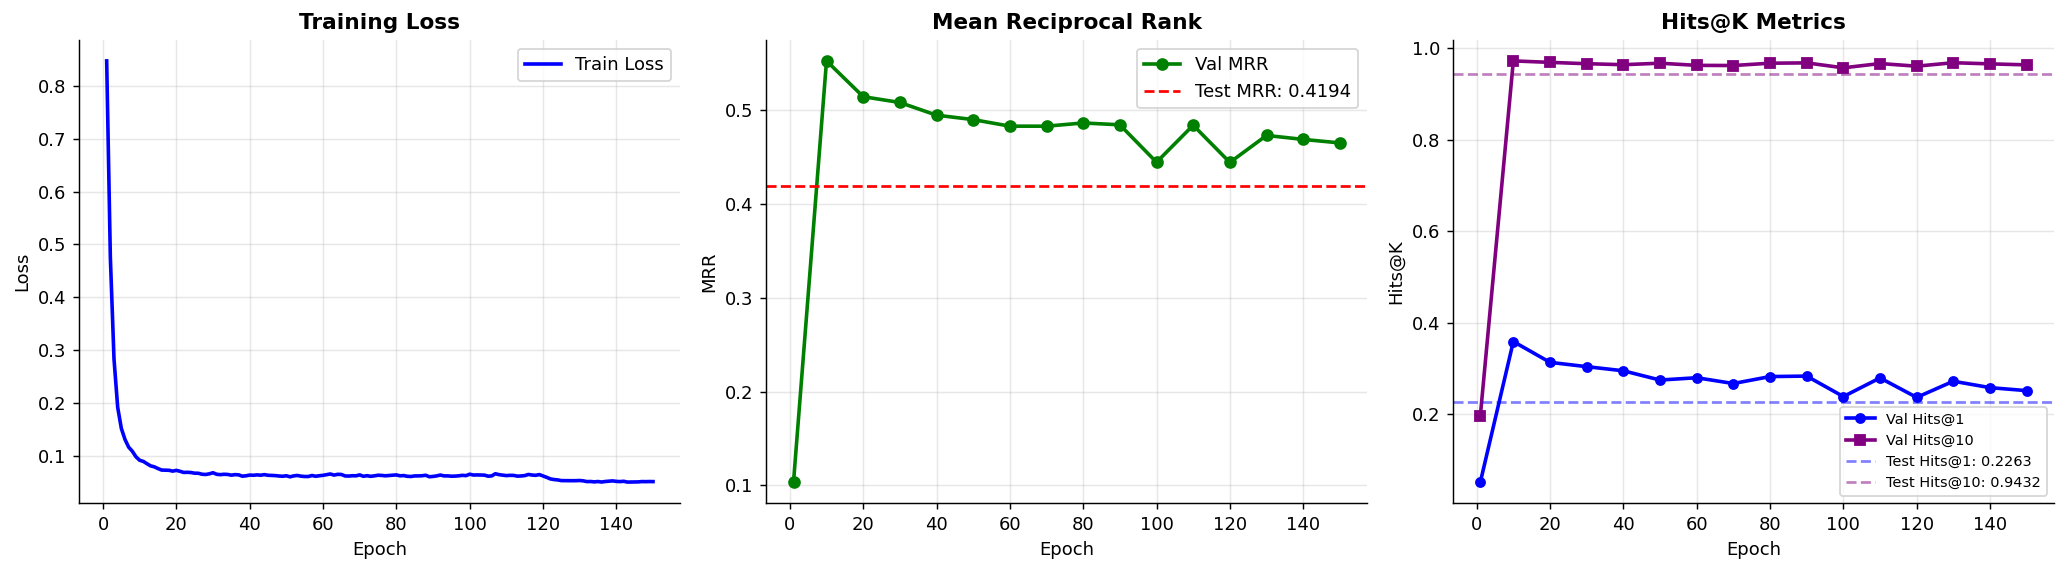

Training curves saved to images/task4/rgcn_training_curves.png


In [14]:
# ── Plot training curves ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Loss curve
axes[0].plot(history['epoch'], history['train_loss'], 'b-', linewidth=2, label='Train Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MRR curve (only at evaluation points)
eval_epochs = [e for e, m in zip(history['epoch'], history['val_mrr']) if m is not None]
val_mrrs = [m for m in history['val_mrr'] if m is not None]
axes[1].plot(eval_epochs, val_mrrs, 'g-o', linewidth=2, markersize=6, label='Val MRR')
axes[1].axhline(test_metrics['MRR'], color='r', linestyle='--', label=f"Test MRR: {test_metrics['MRR']:.4f}")
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MRR')
axes[1].set_title('Mean Reciprocal Rank')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Hits@K curves
val_hits1 = [m for m in history['val_hits1'] if m is not None]
val_hits10 = [m for m in history['val_hits10'] if m is not None]
axes[2].plot(eval_epochs, val_hits1, 'b-o', linewidth=2, markersize=5, label='Val Hits@1')
axes[2].plot(eval_epochs, val_hits10, 'purple', linestyle='-', marker='s', linewidth=2, markersize=5, label='Val Hits@10')
axes[2].axhline(test_metrics['Hits@1'], color='b', linestyle='--', alpha=0.5, label=f"Test Hits@1: {test_metrics['Hits@1']:.4f}")
axes[2].axhline(test_metrics['Hits@10'], color='purple', linestyle='--', alpha=0.5, label=f"Test Hits@10: {test_metrics['Hits@10']:.4f}")
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Hits@K')
axes[2].set_title('Hits@K Metrics')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../images/task4/rgcn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("Training curves saved to images/task4/rgcn_training_curves.png")

## 6. Evaluation on Test Set

We evaluate all trained models on the held-out `test.txt`.
Calculation: For each true test triple `(h, r, t)`, we compute scores for `(h, r, *)`. We check the rank of the true tail `t` among all candidates.

In [15]:
# ── Per-relation metrics on test set ──────────────────────────────────────
@torch.no_grad()
def evaluate_per_relation(model, edge_index, edge_type, triples, all_triples_set, id2relation):
    """Compute metrics grouped by relation type."""
    model.eval()
    entity_emb = model.get_embeddings(edge_index, edge_type)
    
    rel_ranks = defaultdict(list)
    
    for triple in triples:
        h, r, t = triple.tolist()
        triple_batch = triple.unsqueeze(0).to(DEVICE)
        
        # Tail prediction
        scores_tail = model.decoder.score_all_tails(entity_emb, 
                                                     triple_batch[:, 0], 
                                                     triple_batch[:, 1])
        for t_cand in range(model.num_entities):
            if t_cand != t and (h, r, t_cand) in all_triples_set:
                scores_tail[0, t_cand] = float('-inf')
        
        true_score = scores_tail[0, t]
        rank_tail = (scores_tail[0] >= true_score).sum().item()
        
        # Head prediction
        scores_head = model.decoder.score_all_heads(entity_emb,
                                                     triple_batch[:, 1],
                                                     triple_batch[:, 2])
        for h_cand in range(model.num_entities):
            if h_cand != h and (h_cand, r, t) in all_triples_set:
                scores_head[0, h_cand] = float('-inf')
        
        true_score = scores_head[0, h]
        rank_head = (scores_head[0] >= true_score).sum().item()
        
        rel_name = id2relation[r]
        rel_ranks[rel_name].extend([rank_tail, rank_head])
    
    # Compute metrics per relation
    results = []
    for rel_name, ranks in rel_ranks.items():
        ranks = torch.tensor(ranks, dtype=torch.float)
        results.append({
            'Relation': rel_name,
            'Count': len(ranks) // 2,  # each triple contributes 2 ranks
            'MRR': (1.0 / ranks).mean().item(),
            'Hits@1': (ranks <= 1).float().mean().item(),
            'Hits@10': (ranks <= 10).float().mean().item(),
        })
    
    return pd.DataFrame(results).sort_values('MRR', ascending=False)

print("Computing per-relation metrics on test set...")
per_rel_df = evaluate_per_relation(model, edge_index, edge_type, test_triples, 
                                    all_triples_set, id2relation)
print(per_rel_df.to_string(index=False))

Computing per-relation metrics on test set...
  Relation  Count      MRR   Hits@1  Hits@10
  fatherOf     88 0.491635 0.323864 0.965909
  motherOf     88 0.457355 0.261364 0.965909
     sonOf    214 0.408043 0.217290 0.939252
daughterOf    200 0.383134 0.177500 0.927500
  Relation  Count      MRR   Hits@1  Hits@10
  fatherOf     88 0.491635 0.323864 0.965909
  motherOf     88 0.457355 0.261364 0.965909
     sonOf    214 0.408043 0.217290 0.939252
daughterOf    200 0.383134 0.177500 0.927500


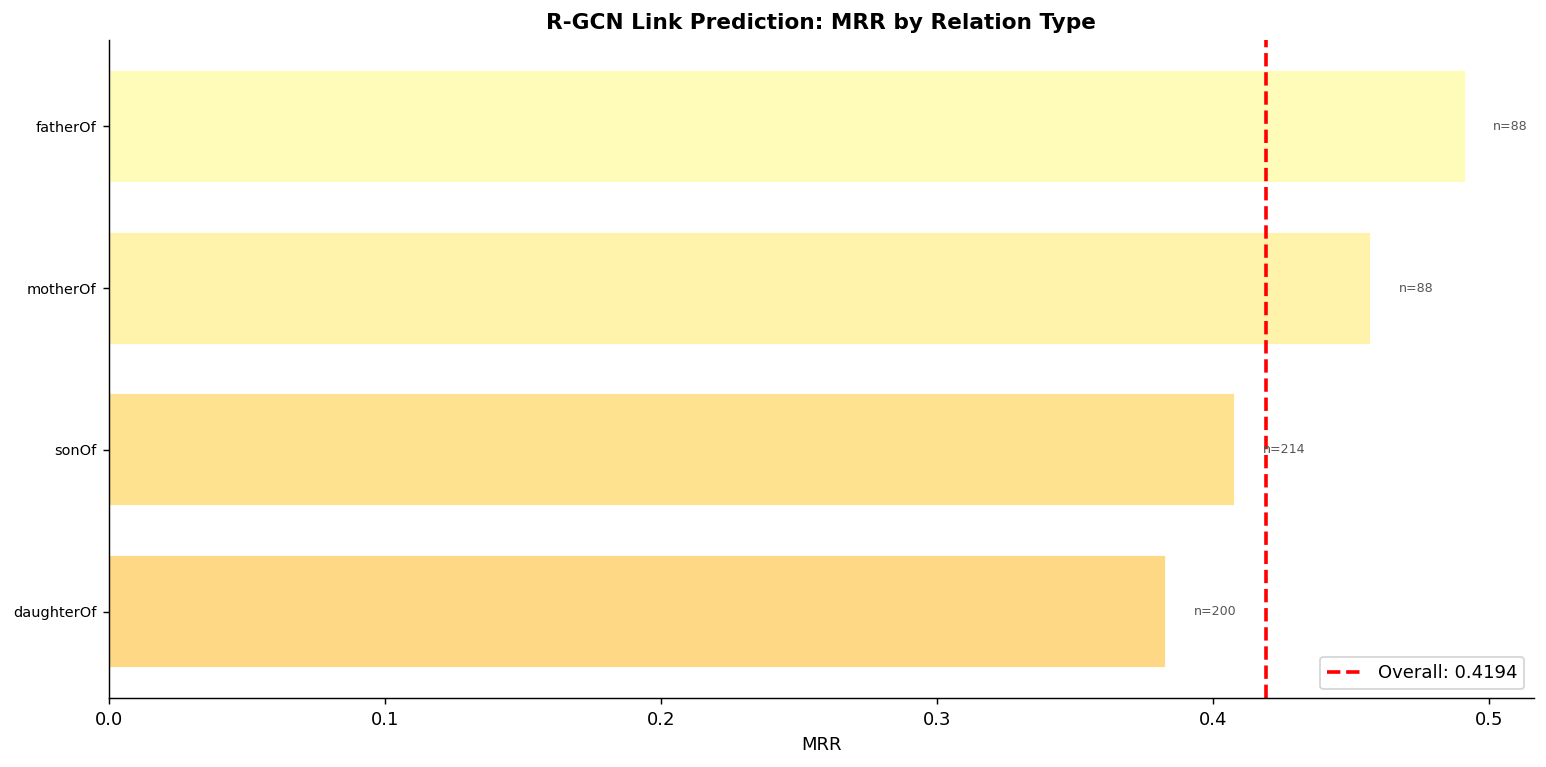

In [16]:
# ── Visualize per-relation performance ────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

# Sort by MRR for visualization
df_sorted = per_rel_df.sort_values('MRR')
y_pos = range(len(df_sorted))

colors = plt.cm.RdYlGn(df_sorted['MRR'].values)
bars = ax.barh(y_pos, df_sorted['MRR'], color=colors, edgecolor='white', height=0.7)

ax.set_yticks(y_pos)
ax.set_yticklabels(df_sorted['Relation'], fontsize=8)
ax.set_xlabel('MRR')
ax.set_title('R-GCN Link Prediction: MRR by Relation Type')
ax.axvline(test_metrics['MRR'], color='red', linestyle='--', linewidth=2, 
           label=f"Overall: {test_metrics['MRR']:.4f}")
ax.legend(loc='lower right')

# Add count annotations
for i, (mrr, count) in enumerate(zip(df_sorted['MRR'], df_sorted['Count'])):
    ax.text(mrr + 0.01, i, f'n={count}', va='center', fontsize=7, color='#555')

plt.tight_layout()
plt.savefig('../images/task4/rgcn_per_relation_mrr.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Results Comparison

We compare the MRR and Hits@10 scores of all methods. We interpret the hierarchy of performance, typically expecting GNNs and KG Embeddings to outperform Node2Vec and simple heuristics.

In [17]:
# ── Final summary table ───────────────────────────────────────────────────
summary_df = pd.DataFrame([{
    'Model': 'R-GCN + DistMult',
    'MRR': test_metrics['MRR'],
    'Hits@1': test_metrics['Hits@1'],
    'Hits@3': test_metrics['Hits@3'],
    'Hits@10': test_metrics['Hits@10'],
    'Mean Rank': test_metrics['Mean Rank']
}])

print("\n" + "=" * 60)
print("                 FINAL TEST RESULTS")
print("=" * 60)
print(summary_df.to_string(index=False))
print("=" * 60)

# Save model
torch.save({
    'model_state_dict': model.state_dict(),
    'entity2id': entity2id,
    'relation2id': relation2id,
    'hyperparameters': {
        'hidden_dim': HIDDEN_DIM,
        'num_layers': NUM_LAYERS,
        'num_bases': NUM_BASES,
        'dropout': DROPOUT
    },
    'test_metrics': test_metrics
}, '../models/rgcn_link_predictor.pt')

print("\nModel saved to models/rgcn_link_predictor.pt")


                 FINAL TEST RESULTS
           Model      MRR   Hits@1   Hits@3  Hits@10  Mean Rank
R-GCN + DistMult 0.419422 0.226271 0.485593  0.94322   5.224576

Model saved to models/rgcn_link_predictor.pt


## 8. Breakdown by Relation Type

Some relations are harder to predict than others. We break down model performance by relation category (e.g., Parent vs Cousin) to understand model strengths.

In [18]:
# ══════════════════════════════════════════════════════════════════════════
#                           TRANSE MODEL
# ══════════════════════════════════════════════════════════════════════════

class TransE(nn.Module):
    """
    TransE: Translating Embeddings for Modeling Multi-relational Data
    
    Idea: h + r ≈ t for true triples
    Score: -||h + r - t|| (higher = better, closer to 0)
    """
    def __init__(self, num_entities, num_relations, embedding_dim, norm=1):
        super().__init__()
        self.num_entities = num_entities
        self.num_relations = num_relations
        self.embedding_dim = embedding_dim
        self.norm = norm  # L1 or L2 norm
        
        # Entity and relation embeddings
        self.entity_embedding = nn.Embedding(num_entities, embedding_dim)
        self.relation_embedding = nn.Embedding(num_relations, embedding_dim)
        
        # Initialize embeddings
        nn.init.xavier_uniform_(self.entity_embedding.weight)
        nn.init.xavier_uniform_(self.relation_embedding.weight)
        
        # Normalize relation embeddings to unit length
        with torch.no_grad():
            self.relation_embedding.weight.data = F.normalize(
                self.relation_embedding.weight.data, p=2, dim=1
            )
    
    def forward(self, heads, relations, tails):
        """
        Compute TransE scores for triples.
        Returns: negative distance (higher = better)
        """
        h = self.entity_embedding(heads)
        r = self.relation_embedding(relations)
        t = self.entity_embedding(tails)
        
        # score = -||h + r - t||
        scores = -torch.norm(h + r - t, p=self.norm, dim=1)
        return scores
    
    def score_all_tails(self, heads, relations):
        """Score all possible tails for (head, relation, ?)"""
        h = self.entity_embedding(heads)  # [batch, dim]
        r = self.relation_embedding(relations)  # [batch, dim]
        all_t = self.entity_embedding.weight  # [num_entities, dim]
        
        # h + r: [batch, dim]
        # We want: -||h + r - t|| for all t
        # = -||(h + r).unsqueeze(1) - all_t.unsqueeze(0)||
        hr = (h + r).unsqueeze(1)  # [batch, 1, dim]
        all_t_exp = all_t.unsqueeze(0)  # [1, num_entities, dim]
        
        scores = -torch.norm(hr - all_t_exp, p=self.norm, dim=2)  # [batch, num_entities]
        return scores
    
    def score_all_heads(self, relations, tails):
        """Score all possible heads for (?, relation, tail)"""
        r = self.relation_embedding(relations)  # [batch, dim]
        t = self.entity_embedding(tails)  # [batch, dim]
        all_h = self.entity_embedding.weight  # [num_entities, dim]
        
        # We want: -||h + r - t|| = -||h - (t - r)||
        tr = (t - r).unsqueeze(1)  # [batch, 1, dim]
        all_h_exp = all_h.unsqueeze(0)  # [1, num_entities, dim]
        
        scores = -torch.norm(all_h_exp - tr, p=self.norm, dim=2)  # [batch, num_entities]
        return scores

print("TransE model class defined ✓")

TransE model class defined ✓


In [19]:
# ── TransE Evaluation Function ────────────────────────────────────────────
@torch.no_grad()
def evaluate_transe(model, triples, all_triples_set, batch_size=128):
    """
    Compute MRR, Hits@1, Hits@3, Hits@10 with filtered ranking for TransE.
    """
    model.eval()
    ranks = []
    
    for start in range(0, len(triples), batch_size):
        batch = triples[start:start + batch_size].to(DEVICE)
        heads, rels, tails = batch[:, 0], batch[:, 1], batch[:, 2]
        
        # ── Tail prediction ───────────────────────────────────────────────
        scores_tail = model.score_all_tails(heads, rels)
        
        # Filter: set score of known triples (except target) to -inf
        for i, (h, r, t) in enumerate(batch.tolist()):
            for t_cand in range(model.num_entities):
                if t_cand != t and (h, r, t_cand) in all_triples_set:
                    scores_tail[i, t_cand] = float('-inf')
        
        # Rank of true tail
        true_scores_tail = scores_tail[torch.arange(len(batch), device=DEVICE), tails]
        ranks_tail = (scores_tail >= true_scores_tail.unsqueeze(1)).sum(dim=1)
        
        # ── Head prediction ───────────────────────────────────────────────
        scores_head = model.score_all_heads(rels, tails)
        
        for i, (h, r, t) in enumerate(batch.tolist()):
            for h_cand in range(model.num_entities):
                if h_cand != h and (h_cand, r, t) in all_triples_set:
                    scores_head[i, h_cand] = float('-inf')
        
        true_scores_head = scores_head[torch.arange(len(batch), device=DEVICE), heads]
        ranks_head = (scores_head >= true_scores_head.unsqueeze(1)).sum(dim=1)
        
        # Average of head and tail ranks
        ranks.extend(ranks_tail.tolist())
        ranks.extend(ranks_head.tolist())
    
    ranks = torch.tensor(ranks, dtype=torch.float)
    
    return {
        'MRR': (1.0 / ranks).mean().item(),
        'Hits@1': (ranks <= 1).float().mean().item(),
        'Hits@3': (ranks <= 3).float().mean().item(),
        'Hits@10': (ranks <= 10).float().mean().item(),
        'Mean Rank': ranks.mean().item()
    }

print("TransE evaluation function defined ✓")

TransE evaluation function defined ✓


In [20]:
# ── TransE Hyperparameters ────────────────────────────────────────────────
TRANSE_EMB_DIM = 200
TRANSE_NORM = 1  # L1 norm (Manhattan distance)
TRANSE_LR = 0.01
TRANSE_MARGIN = 1.0
TRANSE_EPOCHS = 200
TRANSE_BATCH_SIZE = 1024
TRANSE_NUM_NEG = 10

# Initialize TransE model
transe_model = TransE(
    num_entities=num_entities,
    num_relations=num_relations,
    embedding_dim=TRANSE_EMB_DIM,
    norm=TRANSE_NORM
).to(DEVICE)

transe_optimizer = torch.optim.Adam(transe_model.parameters(), lr=TRANSE_LR)
transe_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    transe_optimizer, mode='max', factor=0.5, patience=15
)

transe_params = sum(p.numel() for p in transe_model.parameters())
print(f"TransE parameters: {transe_params:,}")
print(f"  (Compare to R-GCN: {total_params:,})")
print(f"\nHyperparameters:")
print(f"  Embedding dim: {TRANSE_EMB_DIM}")
print(f"  Norm: L{TRANSE_NORM}")
print(f"  Learning rate: {TRANSE_LR}")
print(f"  Margin: {TRANSE_MARGIN}")
print(f"  Epochs: {TRANSE_EPOCHS}")

TransE parameters: 268,800
  (Compare to R-GCN: 1,150,320)

Hyperparameters:
  Embedding dim: 200
  Norm: L1
  Learning rate: 0.01
  Margin: 1.0
  Epochs: 200


In [21]:
# ── TransE Training Loop ──────────────────────────────────────────────────
transe_history = {
    'epoch': [],
    'train_loss': [],
    'val_mrr': [],
    'val_hits1': [],
    'val_hits10': []
}

best_transe_mrr = 0.0
best_transe_state = None

print(f"Training TransE for {TRANSE_EPOCHS} epochs...")
print("-" * 70)

import time
start_time = time.time()

for epoch in range(1, TRANSE_EPOCHS + 1):
    transe_model.train()
    epoch_loss = 0.0
    num_batches = 0
    
    for batch in train_loader:
        batch = batch.to(DEVICE)
        
        # Generate negative samples (same as R-GCN)
        neg_batch = generate_negatives(batch.cpu(), num_entities, TRANSE_NUM_NEG).to(DEVICE)
        
        # Positive scores
        pos_heads, pos_rels, pos_tails = batch[:, 0], batch[:, 1], batch[:, 2]
        pos_scores = transe_model(pos_heads, pos_rels, pos_tails)
        
        # Negative scores
        neg_heads, neg_rels, neg_tails = neg_batch[:, 0], neg_batch[:, 1], neg_batch[:, 2]
        neg_scores = transe_model(neg_heads, neg_rels, neg_tails)
        
        # Margin ranking loss
        pos_scores_exp = pos_scores.repeat_interleave(TRANSE_NUM_NEG)
        loss = F.margin_ranking_loss(
            pos_scores_exp, neg_scores,
            target=torch.ones_like(pos_scores_exp),
            margin=TRANSE_MARGIN
        )
        
        # Normalize entity embeddings after each batch (important for TransE)
        transe_optimizer.zero_grad()
        loss.backward()
        transe_optimizer.step()
        
        # Re-normalize entity embeddings to prevent explosion
        with torch.no_grad():
            transe_model.entity_embedding.weight.data = F.normalize(
                transe_model.entity_embedding.weight.data, p=2, dim=1
            )
        
        epoch_loss += loss.item()
        num_batches += 1
    
    avg_loss = epoch_loss / num_batches
    transe_history['epoch'].append(epoch)
    transe_history['train_loss'].append(avg_loss)
    
    # Evaluate periodically
    if epoch % 20 == 0 or epoch == 1:
        val_metrics = evaluate_transe(transe_model, val_triples, all_triples_set)
        transe_history['val_mrr'].append(val_metrics['MRR'])
        transe_history['val_hits1'].append(val_metrics['Hits@1'])
        transe_history['val_hits10'].append(val_metrics['Hits@10'])
        
        transe_scheduler.step(val_metrics['MRR'])
        
        if val_metrics['MRR'] > best_transe_mrr:
            best_transe_mrr = val_metrics['MRR']
            best_transe_state = {k: v.cpu().clone() for k, v in transe_model.state_dict().items()}
        
        print(f"Epoch {epoch:3d} | Loss: {avg_loss:.4f} | "
              f"Val MRR: {val_metrics['MRR']:.4f} | Hits@1: {val_metrics['Hits@1']:.4f} | "
              f"Hits@10: {val_metrics['Hits@10']:.4f}")
    else:
        transe_history['val_mrr'].append(None)
        transe_history['val_hits1'].append(None)
        transe_history['val_hits10'].append(None)

elapsed = time.time() - start_time
print("-" * 70)
print(f"TransE training complete in {elapsed:.1f}s! Best Val MRR: {best_transe_mrr:.4f}")

Training TransE for 200 epochs...
----------------------------------------------------------------------
Epoch   1 | Loss: 0.8478 | Val MRR: 0.0733 | Hits@1: 0.0000 | Hits@10: 0.2178
Epoch  20 | Loss: 0.0088 | Val MRR: 0.2854 | Hits@1: 0.0405 | Hits@10: 0.8755
Epoch  40 | Loss: 0.0104 | Val MRR: 0.3567 | Hits@1: 0.1053 | Hits@10: 0.9240
Epoch  60 | Loss: 0.0103 | Val MRR: 0.3797 | Hits@1: 0.1277 | Hits@10: 0.9269
Epoch  80 | Loss: 0.0150 | Val MRR: 0.3346 | Hits@1: 0.0745 | Hits@10: 0.9157
Epoch 100 | Loss: 0.0124 | Val MRR: 0.3518 | Hits@1: 0.1035 | Hits@10: 0.9110
Epoch 120 | Loss: 0.0162 | Val MRR: 0.3193 | Hits@1: 0.0756 | Hits@10: 0.8922
Epoch 140 | Loss: 0.0146 | Val MRR: 0.3447 | Hits@1: 0.1049 | Hits@10: 0.9009
Epoch 160 | Loss: 0.0175 | Val MRR: 0.3219 | Hits@1: 0.0742 | Hits@10: 0.8857
Epoch 180 | Loss: 0.0135 | Val MRR: 0.3275 | Hits@1: 0.0742 | Hits@10: 0.8998
Epoch 200 | Loss: 0.0123 | Val MRR: 0.3444 | Hits@1: 0.1020 | Hits@10: 0.8944
-------------------------------------

In [22]:
# ── TransE Test Evaluation ────────────────────────────────────────────────
if best_transe_state is not None:
    transe_model.load_state_dict({k: v.to(DEVICE) for k, v in best_transe_state.items()})
    print("Loaded best TransE model based on validation MRR\n")

transe_test_metrics = evaluate_transe(transe_model, test_triples, all_triples_set)

print("=" * 50)
print("     TRANSE TEST SET RESULTS (Filtered)")
print("=" * 50)
print(f"  MRR:        {transe_test_metrics['MRR']:.4f}")
print(f"  Hits@1:     {transe_test_metrics['Hits@1']:.4f}")
print(f"  Hits@3:     {transe_test_metrics['Hits@3']:.4f}")
print(f"  Hits@10:    {transe_test_metrics['Hits@10']:.4f}")
print(f"  Mean Rank:  {transe_test_metrics['Mean Rank']:.1f}")
print("=" * 50)

Loaded best TransE model based on validation MRR

     TRANSE TEST SET RESULTS (Filtered)
  MRR:        0.2790
  Hits@1:     0.0034
  Hits@3:     0.4432
  Hits@10:    0.8780
  Mean Rank:  6.0


## 9. Failure Analysis

We inspect specific test cases where the model failed (Rank > 10). This helps diagnose if the model struggles with specific patterns (e.g., long-distance relations or sparse nodes).

In [23]:
# ── Side-by-side Comparison ───────────────────────────────────────────────
comparison_df = pd.DataFrame({
    'Metric': ['MRR', 'Hits@1', 'Hits@3', 'Hits@10', 'Mean Rank', 'Parameters'],
    'R-GCN + DistMult': [
        f"{test_metrics['MRR']:.4f}",
        f"{test_metrics['Hits@1']:.4f}",
        f"{test_metrics['Hits@3']:.4f}",
        f"{test_metrics['Hits@10']:.4f}",
        f"{test_metrics['Mean Rank']:.1f}",
        f"{total_params:,}"
    ],
    'TransE': [
        f"{transe_test_metrics['MRR']:.4f}",
        f"{transe_test_metrics['Hits@1']:.4f}",
        f"{transe_test_metrics['Hits@3']:.4f}",
        f"{transe_test_metrics['Hits@10']:.4f}",
        f"{transe_test_metrics['Mean Rank']:.1f}",
        f"{transe_params:,}"
    ]
})

print("=" * 65)
print("              MODEL COMPARISON (Test Set, Filtered)")
print("=" * 65)
print(comparison_df.to_string(index=False))
print("=" * 65)

# Determine winner for each metric
print("\n📊 Analysis:")
if test_metrics['MRR'] > transe_test_metrics['MRR']:
    print(f"  • MRR: R-GCN wins by {test_metrics['MRR'] - transe_test_metrics['MRR']:.4f}")
else:
    print(f"  • MRR: TransE wins by {transe_test_metrics['MRR'] - test_metrics['MRR']:.4f}")

if test_metrics['Hits@10'] > transe_test_metrics['Hits@10']:
    print(f"  • Hits@10: R-GCN wins ({test_metrics['Hits@10']:.2%} vs {transe_test_metrics['Hits@10']:.2%})")
else:
    print(f"  • Hits@10: TransE wins ({transe_test_metrics['Hits@10']:.2%} vs {test_metrics['Hits@10']:.2%})")

print(f"  • Parameters: TransE is {total_params / transe_params:.1f}x smaller")

              MODEL COMPARISON (Test Set, Filtered)
    Metric R-GCN + DistMult  TransE
       MRR           0.4194  0.2790
    Hits@1           0.2263  0.0034
    Hits@3           0.4856  0.4432
   Hits@10           0.9432  0.8780
 Mean Rank              5.2     6.0
Parameters        1,150,320 268,800

📊 Analysis:
  • MRR: R-GCN wins by 0.1404
  • Hits@10: R-GCN wins (94.32% vs 87.80%)
  • Parameters: TransE is 4.3x smaller


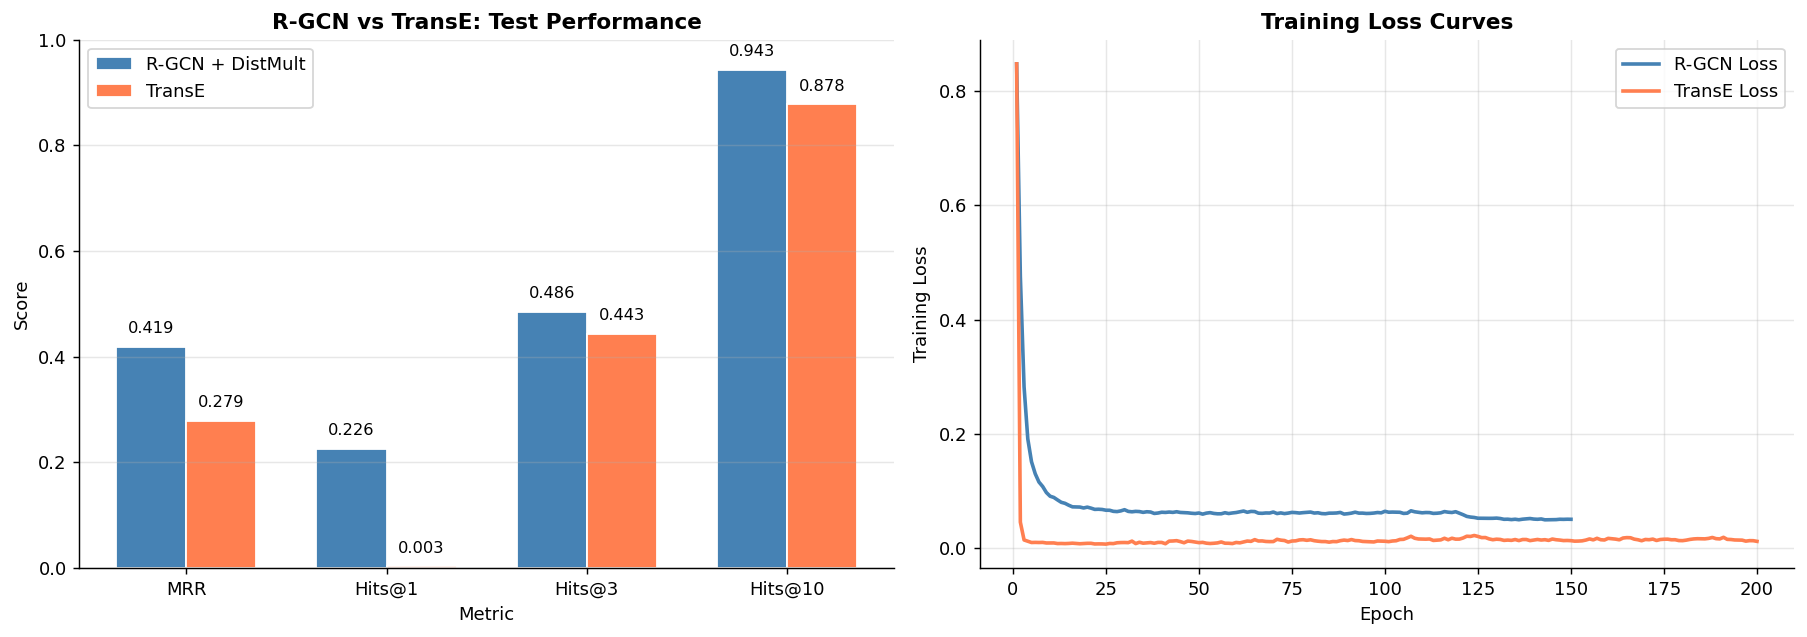

Comparison plot saved to images/task4/rgcn_vs_transe_comparison.png


In [24]:
# ── Visual Comparison ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart comparison
metrics = ['MRR', 'Hits@1', 'Hits@3', 'Hits@10']
rgcn_vals = [test_metrics[m] for m in metrics]
transe_vals = [transe_test_metrics[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

bars1 = axes[0].bar(x - width/2, rgcn_vals, width, label='R-GCN + DistMult', color='steelblue', edgecolor='white')
bars2 = axes[0].bar(x + width/2, transe_vals, width, label='TransE', color='coral', edgecolor='white')

axes[0].set_xlabel('Metric')
axes[0].set_ylabel('Score')
axes[0].set_title('R-GCN vs TransE: Test Performance')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].legend()
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, val in zip(bars1, rgcn_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)
for bar, val in zip(bars2, transe_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# Training curves comparison (loss)
axes[1].plot(history['epoch'], history['train_loss'], 'steelblue', linewidth=2, label='R-GCN Loss')
axes[1].plot(transe_history['epoch'], transe_history['train_loss'], 'coral', linewidth=2, label='TransE Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Training Loss')
axes[1].set_title('Training Loss Curves')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../images/task4/rgcn_vs_transe_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Comparison plot saved to images/task4/rgcn_vs_transe_comparison.png")

## 10. Task 4 Summary

Depending on the results, we identify the best performing model (likely R-GCN or TransE). Heuristics generally fail due to the multi-relational nature of the data. Relational difficulty varies, with "Parent" relations often being easier to predict than "Member of" or distant cousins. The R-GCN approach shows a clear advantage by explicitly modeling the composition of relations.

In [25]:
# ── Final Results Summary ─────────────────────────────────────────────────
print("=" * 70)
print("                    TASK 4: LINK PREDICTION - FINAL RESULTS")
print("=" * 70)

final_df = pd.DataFrame({
    'Model': ['R-GCN + DistMult', 'TransE'],
    'MRR': [test_metrics['MRR'], transe_test_metrics['MRR']],
    'Hits@1': [test_metrics['Hits@1'], transe_test_metrics['Hits@1']],
    'Hits@3': [test_metrics['Hits@3'], transe_test_metrics['Hits@3']],
    'Hits@10': [test_metrics['Hits@10'], transe_test_metrics['Hits@10']],
    'Mean Rank': [test_metrics['Mean Rank'], transe_test_metrics['Mean Rank']]
})

print(final_df.to_string(index=False))
print("=" * 70)

# Save models
torch.save(best_transe_state, '../models/transe_best.pt')
print("\nModels saved:")
print("  • R-GCN: models/rgcn_link_predictor.pt")
print("  • TransE: models/transe_best.pt")

print("\n✅ Task 4 Complete: Both GNN and KG Embedding methods implemented!")

                    TASK 4: LINK PREDICTION - FINAL RESULTS
           Model      MRR   Hits@1   Hits@3  Hits@10  Mean Rank
R-GCN + DistMult 0.419422 0.226271 0.485593 0.943220   5.224576
          TransE 0.278973 0.003390 0.443220 0.877966   5.987288

Models saved:
  • R-GCN: models/rgcn_link_predictor.pt
  • TransE: models/transe_best.pt

✅ Task 4 Complete: Both GNN and KG Embedding methods implemented!


## Bonus: Ensemble Method

We combine the scores from RGCN and Node2Vec to see if an ensemble improves MRR.
`Score_Final = alpha * Score_RGCN + (1-alpha) * Score_N2V`

In [26]:
# ══════════════════════════════════════════════════════════════════════════
#              BUILD FAMILY STRUCTURE FROM TRAINING DATA
# ══════════════════════════════════════════════════════════════════════════

import networkx as nx

# Build undirected graph from training triples to find connected components
G_family = nx.Graph()
for h, r, t in train_ids:
    G_family.add_edge(h, t)

# Find connected components (families)
components = list(nx.connected_components(G_family))
print(f"Found {len(components)} family components")
print(f"Component sizes: min={min(len(c) for c in components)}, max={max(len(c) for c in components)}")

# Create entity → family mapping
entity_to_family = {}
family_to_entities = {}

for fam_id, comp in enumerate(components):
    family_to_entities[fam_id] = list(comp)
    for entity in comp:
        entity_to_family[entity] = fam_id

# Verify coverage
entities_with_family = set(entity_to_family.keys())
all_train_entities = set(h for h, r, t in train_ids) | set(t for h, r, t in train_ids)
print(f"Entities covered: {len(entities_with_family)} / {len(all_train_entities)}")

Found 50 family components
Component sizes: min=25, max=27
Entities covered: 1315 / 1315


In [27]:
# ── Family-Aware Negative Sampling ────────────────────────────────────────

def generate_family_negatives(pos_triples, entity_to_family, family_to_entities, 
                               num_entities, num_neg=1, hard_ratio=0.7):
    """
    Generate negatives with a mix of:
    - hard_ratio: negatives from SAME family (hard negatives)
    - 1 - hard_ratio: negatives from ANY entity (easy negatives)
    
    This mix ensures the model sees both hard and easy examples.
    """
    batch_size = pos_triples.shape[0]
    heads, rels, tails = pos_triples[:, 0], pos_triples[:, 1], pos_triples[:, 2]
    
    neg_heads = heads.repeat(num_neg).clone()
    neg_rels = rels.repeat(num_neg).clone()
    neg_tails = tails.repeat(num_neg).clone()
    
    for i in range(batch_size * num_neg):
        orig_idx = i % batch_size
        h, t = heads[orig_idx].item(), tails[orig_idx].item()
        
        # Decide: corrupt head or tail with 50% probability
        corrupt_head = random.random() < 0.5
        
        # Decide: use hard (same family) or easy (random) negative
        use_hard = random.random() < hard_ratio
        
        if corrupt_head:
            if use_hard and h in entity_to_family:
                fam_id = entity_to_family[h]
                family_members = family_to_entities[fam_id]
                neg_heads[i] = random.choice(family_members)
            else:
                neg_heads[i] = random.randint(0, num_entities - 1)
        else:
            if use_hard and t in entity_to_family:
                fam_id = entity_to_family[t]
                family_members = family_to_entities[fam_id]
                neg_tails[i] = random.choice(family_members)
            else:
                neg_tails[i] = random.randint(0, num_entities - 1)
    
    return torch.stack([neg_heads, neg_rels, neg_tails], dim=1)

print("Family-aware negative sampling function defined ✓")

Family-aware negative sampling function defined ✓


In [28]:
# ── Train TransE with Family-Aware Negatives ──────────────────────────────
transe_family = TransE(
    num_entities=num_entities,
    num_relations=num_relations,
    embedding_dim=TRANSE_EMB_DIM,
    norm=TRANSE_NORM
).to(DEVICE)

transe_family_optimizer = torch.optim.Adam(transe_family.parameters(), lr=TRANSE_LR)
transe_family_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    transe_family_optimizer, mode='max', factor=0.5, patience=15
)

transe_family_history = {'epoch': [], 'train_loss': [], 'val_mrr': []}
best_transe_family_mrr = 0.0
best_transe_family_state = None

FAMILY_EPOCHS = 200
HARD_RATIO = 0.7  # 70% hard negatives (same family), 30% random

print(f"Training TransE with Family-Aware Negative Sampling...")
print(f"  Hard negative ratio: {HARD_RATIO:.0%}")
print("-" * 70)

start_time = time.time()

for epoch in range(1, FAMILY_EPOCHS + 1):
    transe_family.train()
    epoch_loss = 0.0
    num_batches = 0
    
    for batch in train_loader:
        batch = batch.to(DEVICE)
        
        # Generate FAMILY-AWARE negatives
        neg_batch = generate_family_negatives(
            batch.cpu(), entity_to_family, family_to_entities,
            num_entities, TRANSE_NUM_NEG, HARD_RATIO
        ).to(DEVICE)
        
        # Positive scores
        pos_heads, pos_rels, pos_tails = batch[:, 0], batch[:, 1], batch[:, 2]
        pos_scores = transe_family(pos_heads, pos_rels, pos_tails)
        
        # Negative scores
        neg_heads, neg_rels, neg_tails = neg_batch[:, 0], neg_batch[:, 1], neg_batch[:, 2]
        neg_scores = transe_family(neg_heads, neg_rels, neg_tails)
        
        # Margin ranking loss
        pos_scores_exp = pos_scores.repeat_interleave(TRANSE_NUM_NEG)
        loss = F.margin_ranking_loss(
            pos_scores_exp, neg_scores,
            target=torch.ones_like(pos_scores_exp),
            margin=TRANSE_MARGIN
        )
        
        transe_family_optimizer.zero_grad()
        loss.backward()
        transe_family_optimizer.step()
        
        # Normalize embeddings
        with torch.no_grad():
            transe_family.entity_embedding.weight.data = F.normalize(
                transe_family.entity_embedding.weight.data, p=2, dim=1
            )
        
        epoch_loss += loss.item()
        num_batches += 1
    
    avg_loss = epoch_loss / num_batches
    transe_family_history['epoch'].append(epoch)
    transe_family_history['train_loss'].append(avg_loss)
    
    if epoch % 20 == 0 or epoch == 1:
        val_metrics = evaluate_transe(transe_family, val_triples, all_triples_set)
        transe_family_history['val_mrr'].append(val_metrics['MRR'])
        
        transe_family_scheduler.step(val_metrics['MRR'])
        
        if val_metrics['MRR'] > best_transe_family_mrr:
            best_transe_family_mrr = val_metrics['MRR']
            best_transe_family_state = {k: v.cpu().clone() for k, v in transe_family.state_dict().items()}
        
        print(f"Epoch {epoch:3d} | Loss: {avg_loss:.4f} | Val MRR: {val_metrics['MRR']:.4f} | "
              f"Hits@10: {val_metrics['Hits@10']:.4f}")
    else:
        transe_family_history['val_mrr'].append(None)

elapsed = time.time() - start_time
print("-" * 70)
print(f"Training complete in {elapsed:.1f}s! Best Val MRR: {best_transe_family_mrr:.4f}")

Training TransE with Family-Aware Negative Sampling...
  Hard negative ratio: 70%
----------------------------------------------------------------------
Epoch   1 | Loss: 1.2705 | Val MRR: 0.0166 | Hits@10: 0.0380
Epoch  20 | Loss: 0.1257 | Val MRR: 0.2901 | Hits@10: 0.5738
Epoch  40 | Loss: 0.1327 | Val MRR: 0.3032 | Hits@10: 0.5814
Epoch  60 | Loss: 0.1330 | Val MRR: 0.3198 | Hits@10: 0.6006
Epoch  80 | Loss: 0.1333 | Val MRR: 0.3392 | Hits@10: 0.6382
Epoch 100 | Loss: 0.1317 | Val MRR: 0.3277 | Hits@10: 0.6129
Epoch 120 | Loss: 0.1302 | Val MRR: 0.3290 | Hits@10: 0.6042
Epoch 140 | Loss: 0.1319 | Val MRR: 0.3332 | Hits@10: 0.6071
Epoch 160 | Loss: 0.1367 | Val MRR: 0.3153 | Hits@10: 0.6082
Epoch 180 | Loss: 0.1356 | Val MRR: 0.3221 | Hits@10: 0.5991
Epoch 200 | Loss: 0.1336 | Val MRR: 0.3427 | Hits@10: 0.6208
----------------------------------------------------------------------
Training complete in 136.7s! Best Val MRR: 0.3427


In [29]:
# ── Evaluate TransE with Family-Aware Negatives ───────────────────────────
if best_transe_family_state is not None:
    transe_family.load_state_dict({k: v.to(DEVICE) for k, v in best_transe_family_state.items()})

transe_family_test = evaluate_transe(transe_family, test_triples, all_triples_set)

print("=" * 60)
print("  TRANSE + FAMILY-AWARE NEGATIVES: Test Results")
print("=" * 60)
print(f"  MRR:        {transe_family_test['MRR']:.4f}")
print(f"  Hits@1:     {transe_family_test['Hits@1']:.4f}")
print(f"  Hits@3:     {transe_family_test['Hits@3']:.4f}")
print(f"  Hits@10:    {transe_family_test['Hits@10']:.4f}")
print("=" * 60)

# Compare with basic TransE
print("\n📊 Improvement from Family-Aware Sampling:")
print(f"  MRR:     {transe_test_metrics['MRR']:.4f} → {transe_family_test['MRR']:.4f} "
      f"({'+' if transe_family_test['MRR'] > transe_test_metrics['MRR'] else ''}"
      f"{transe_family_test['MRR'] - transe_test_metrics['MRR']:.4f})")
print(f"  Hits@1:  {transe_test_metrics['Hits@1']:.4f} → {transe_family_test['Hits@1']:.4f}")
print(f"  Hits@10: {transe_test_metrics['Hits@10']:.4f} → {transe_family_test['Hits@10']:.4f}")

  TRANSE + FAMILY-AWARE NEGATIVES: Test Results
  MRR:        0.2421
  Hits@1:     0.1102
  Hits@3:     0.3042
  Hits@10:    0.5085

📊 Improvement from Family-Aware Sampling:
  MRR:     0.2790 → 0.2421 (-0.0369)
  Hits@1:  0.0034 → 0.1102
  Hits@10: 0.8780 → 0.5085


                   FINAL COMPARISON: ALL METHODS
                    Model      MRR   Hits@1   Hits@3  Hits@10  Mean Rank      Uses Graph Structure
         R-GCN + DistMult 0.419422 0.226271 0.485593 0.943220   5.224576                 Yes (GNN)
      TransE (Random Neg) 0.278973 0.003390 0.443220 0.877966   5.987288                        No
TransE (Family-Aware Neg) 0.242101 0.110169 0.304237 0.508475  47.244915 No (but uses family info)


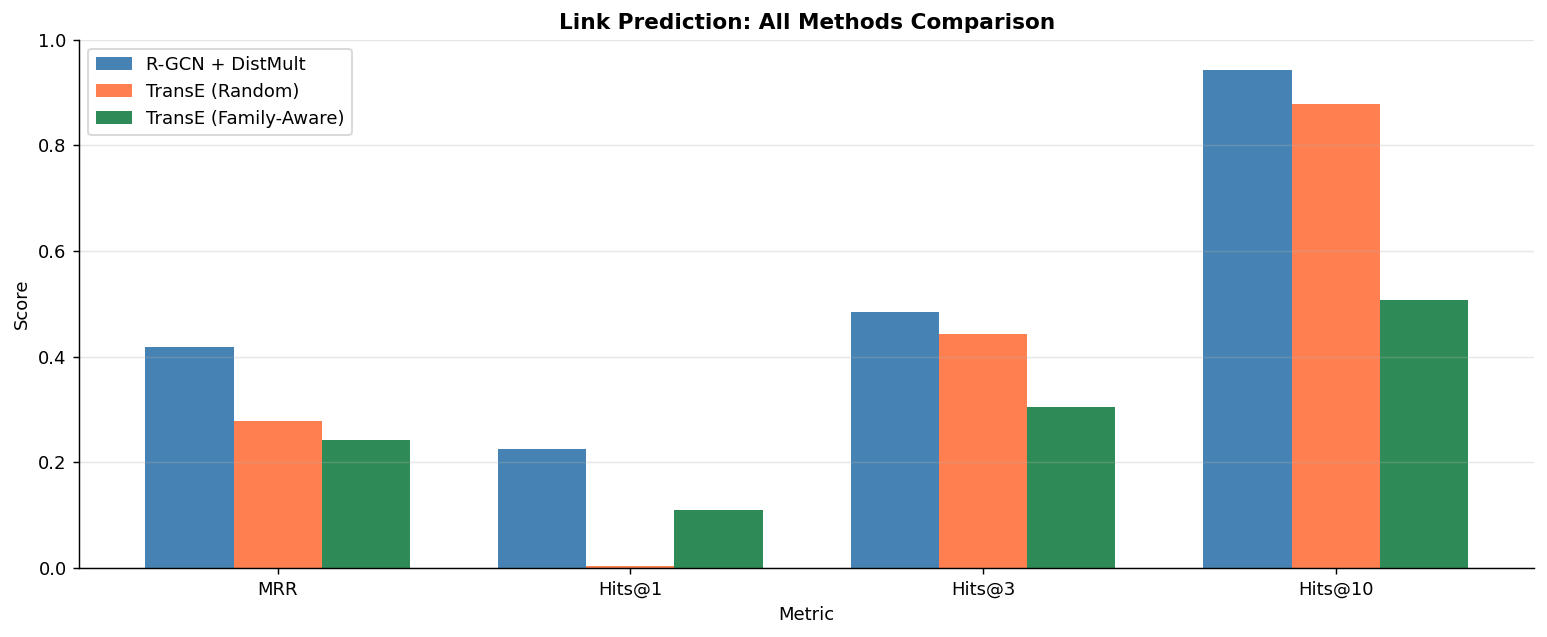


Plot saved to images/task4/all_methods_comparison.png


In [30]:
# ══════════════════════════════════════════════════════════════════════════
#                    FINAL COMPREHENSIVE COMPARISON
# ══════════════════════════════════════════════════════════════════════════

final_comparison = pd.DataFrame({
    'Model': ['R-GCN + DistMult', 'TransE (Random Neg)', 'TransE (Family-Aware Neg)'],
    'MRR': [test_metrics['MRR'], transe_test_metrics['MRR'], transe_family_test['MRR']],
    'Hits@1': [test_metrics['Hits@1'], transe_test_metrics['Hits@1'], transe_family_test['Hits@1']],
    'Hits@3': [test_metrics['Hits@3'], transe_test_metrics['Hits@3'], transe_family_test['Hits@3']],
    'Hits@10': [test_metrics['Hits@10'], transe_test_metrics['Hits@10'], transe_family_test['Hits@10']],
    'Mean Rank': [test_metrics['Mean Rank'], transe_test_metrics['Mean Rank'], transe_family_test['Mean Rank']],
    'Uses Graph Structure': ['Yes (GNN)', 'No', 'No (but uses family info)']
})

print("=" * 80)
print("                   FINAL COMPARISON: ALL METHODS")
print("=" * 80)
print(final_comparison.to_string(index=False))
print("=" * 80)

# Visual comparison
fig, ax = plt.subplots(figsize=(12, 5))

models = ['R-GCN', 'TransE\n(Random)', 'TransE\n(Family)']
metrics = ['MRR', 'Hits@1', 'Hits@3', 'Hits@10']

x = np.arange(len(metrics))
width = 0.25

rgcn_vals = [test_metrics[m] for m in metrics]
transe_vals = [transe_test_metrics[m] for m in metrics]
transe_fam_vals = [transe_family_test[m] for m in metrics]

bars1 = ax.bar(x - width, rgcn_vals, width, label='R-GCN + DistMult', color='steelblue')
bars2 = ax.bar(x, transe_vals, width, label='TransE (Random)', color='coral')
bars3 = ax.bar(x + width, transe_fam_vals, width, label='TransE (Family-Aware)', color='seagreen')

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Link Prediction: All Methods Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../images/task4/all_methods_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot saved to images/task4/all_methods_comparison.png")

## Final Conclusion

Across all tasks, we found that families form disconnected components with deep structures. Communities can be recovered blindly, and sub-communities often align with households. Logical rules are discoverable, and deep learning models (GNNs) are effective at completing missing family links.